In [1]:
import os

import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats
from astropy.coordinates import SkyCoord
from astropy.io import fits
from gammapy.irf import load_irf_dict_from_file
from scipy.stats import chi2, poisson

**Adjust with the correct file paths**

In [2]:
blazar_coord = SkyCoord.from_name("Mrk 501")
data_folder = "../cta_dc_data/mrk_501/"
irf_file = "../cta_dc_data/irfs/Prod5-North-40deg-AverageAz-4LSTs09MSTs.180000s-v0.1.fits.gz"

In [3]:
blazar_l = blazar_coord.galactic.l.deg
blazar_b = blazar_coord.galactic.b.deg

hbus = []
for filename in os.listdir(data_folder):
    hbus.append(fits.open(data_folder + filename))

irf = load_irf_dict_from_file(irf_file)
aeff = irf["aeff"]
print(f"Pointings: {len(hbus)}")

Pointings: 126


In [4]:
e_bins=np.logspace(np.log10(0.05), np.log10(50), 16)
e_mins=e_bins[:-1]
e_maxs=e_bins[1:]
e=np.sqrt(e_mins*e_maxs)
de=e_maxs-e_mins

th2_bins=np.linspace(0,0.16,17)
th2=(th2_bins[1:]+th2_bins[:-1])/2.

**Data collecting and overview**

In [5]:
bkg_subtraction_radius = 0.4

cts_s = np.zeros((len(e), len(th2)))
cts_b = np.zeros((len(e), len(th2)))

t_expo = 0

for hbu in hbus:
    data_raw = hbu["EVENTS"].data

    t = data_raw["TIME"]
    t = np.sort(t)
    t_expo += t[-1] - t[0]

    coord = SkyCoord(
        ra=data_raw["RA"] * u.deg, dec=data_raw["DEC"] * u.deg, frame="icrs"
    )

    pointing_coord = SkyCoord(
        ra=hbu[1].header["RA_PNT"] * u.deg,
        dec=hbu[1].header["DEC_PNT"] * u.deg,
        frame="icrs",
    )

    bkg_center = SkyCoord(
        l=2 * pointing_coord.galactic.l - blazar_coord.galactic.l,
        b=2 * pointing_coord.galactic.b - blazar_coord.galactic.b,
        frame="galactic",
    )
    
    seps = coord.separation(blazar_coord).degree
    seps_b = coord.separation(bkg_center).degree
    src_pos_mask = seps < bkg_subtraction_radius
    bkg_pos_mask = seps_b < bkg_subtraction_radius

    e = data_raw["ENERGY_TRUE"]

    for i, (energ_min, energ_max) in enumerate(zip(e_mins, e_maxs)):
        m_s = (e>energ_min) & (e<energ_max) & src_pos_mask
        m_b = (e>energ_min) & (e<energ_max )& bkg_pos_mask

        h_s, _ = np.histogram(seps[m_s]**2, bins=th2_bins)
        h_b, _ = np.histogram(seps_b[m_b]**2, bins=th2_bins)
        
        cts_s[i] += h_s
        cts_b[i] += h_b

print(f"Exposure time = {t_expo/60/60:.1f}h")

Exposure time = 17.8h


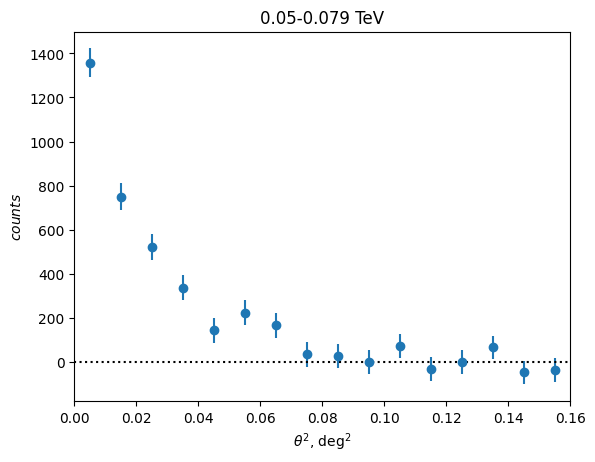

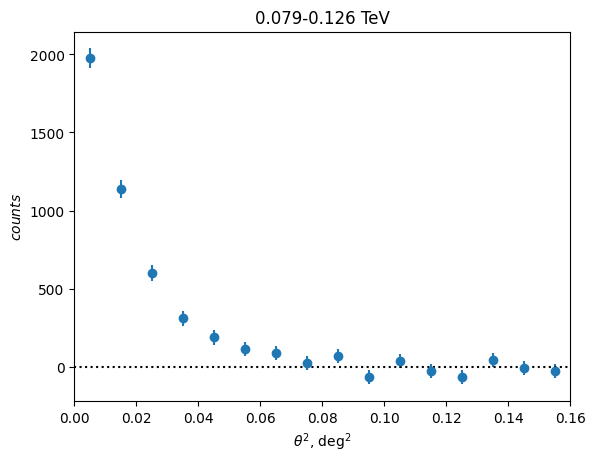

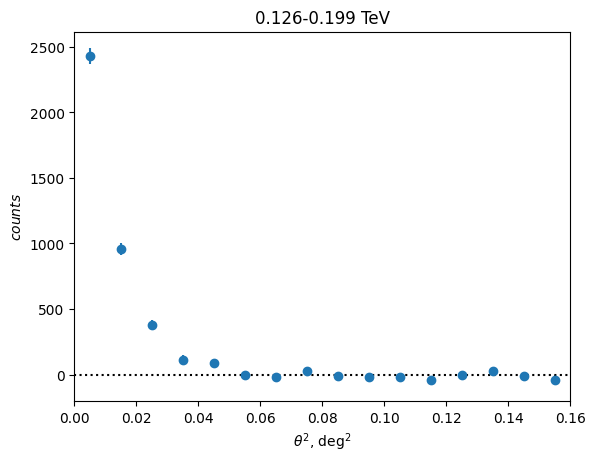

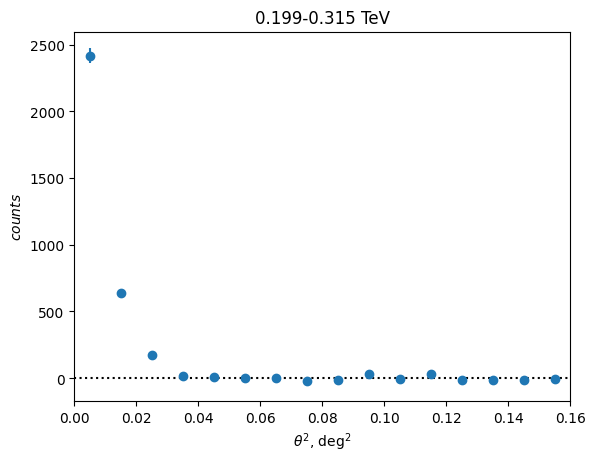

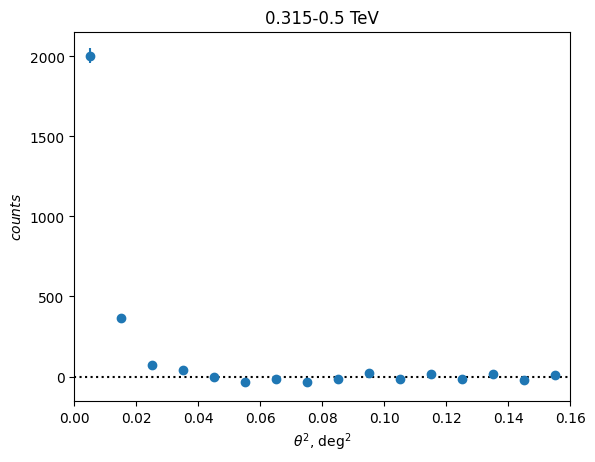

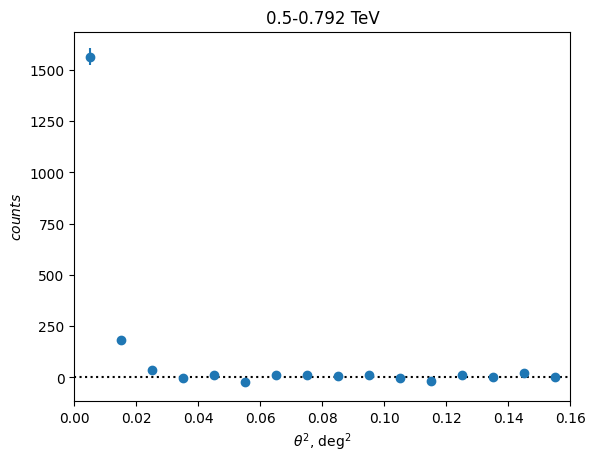

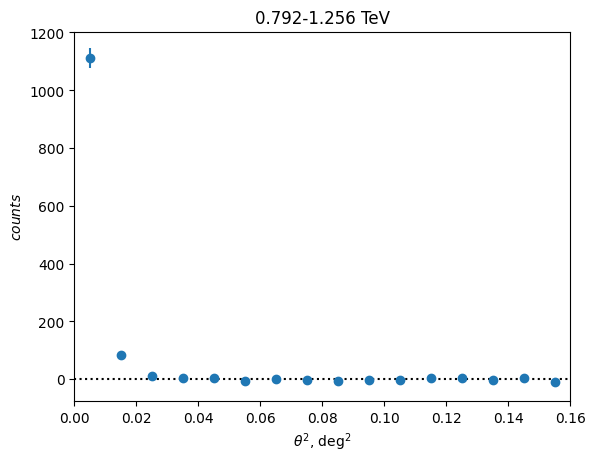

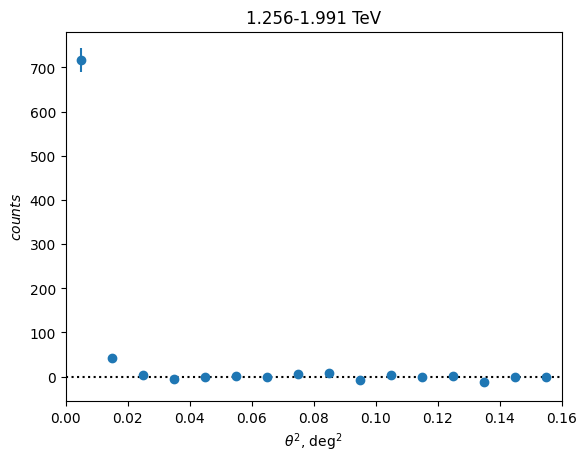

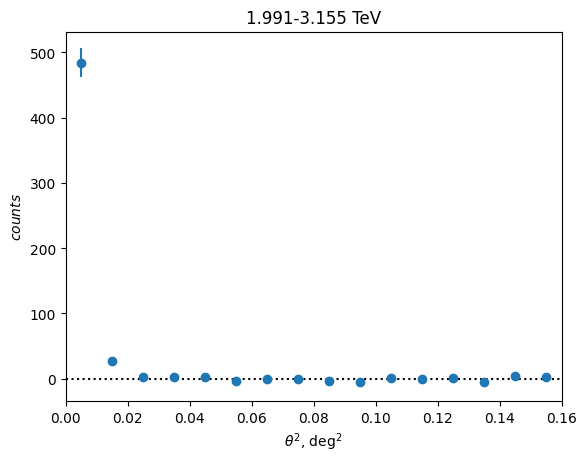

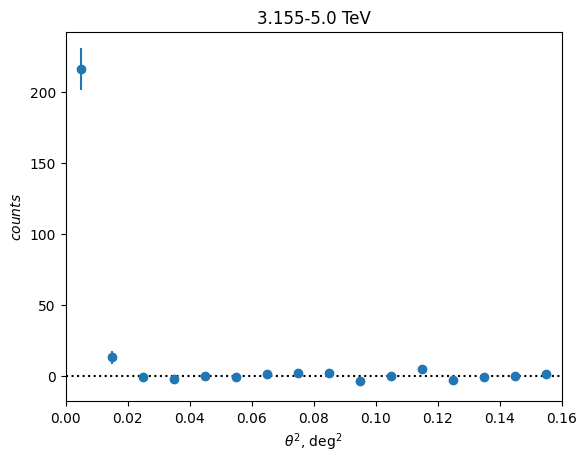

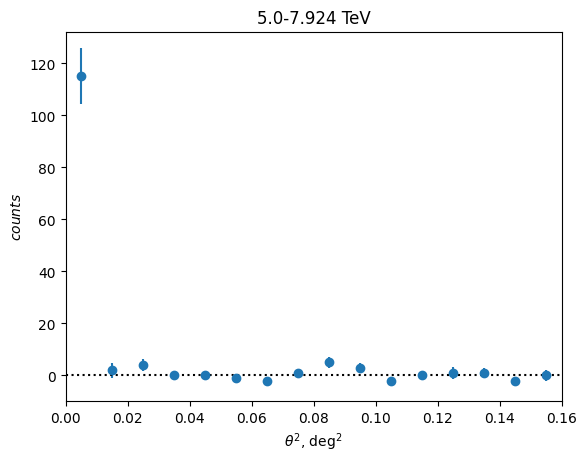

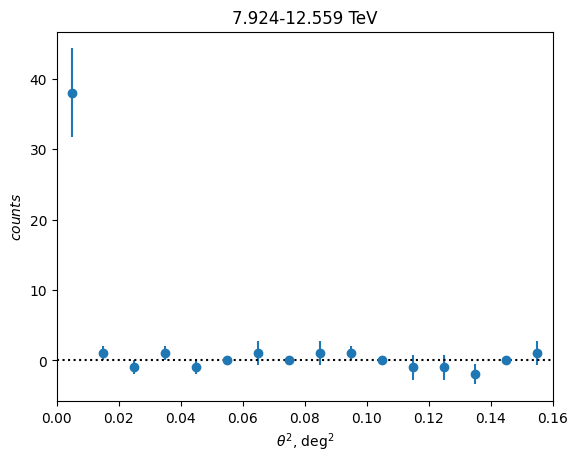

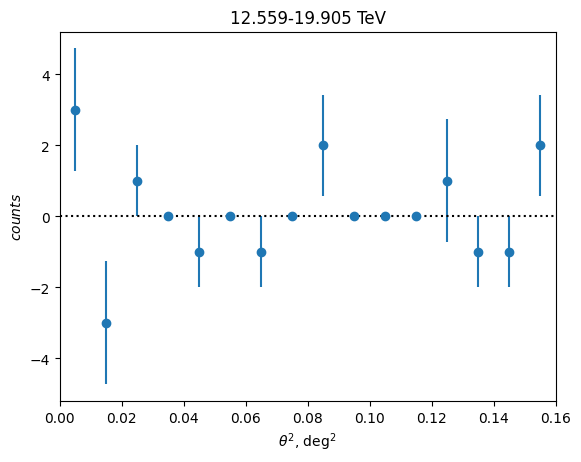

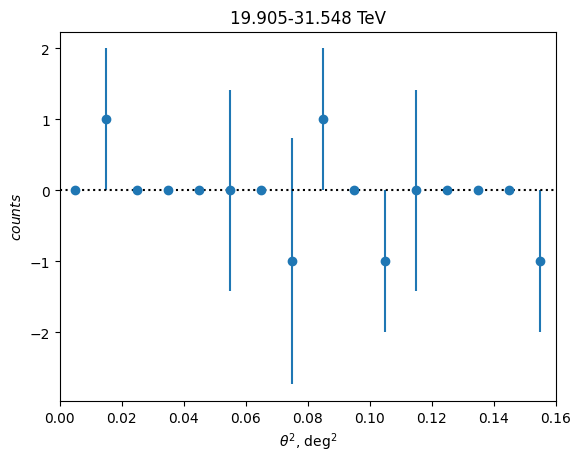

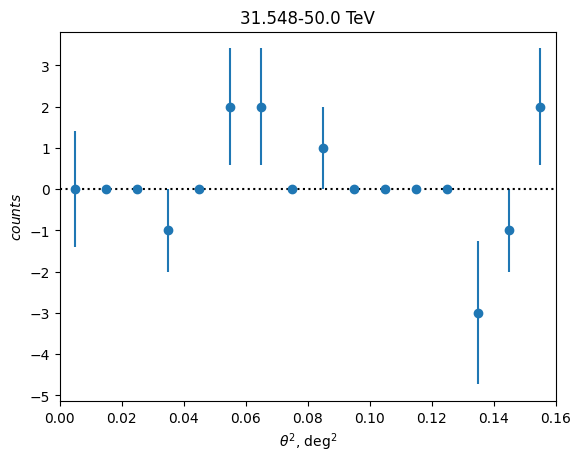

In [6]:
cts = cts_s - cts_b
cts_err = np.sqrt(cts_s + cts_b)

for i in range(cts.shape[0]):
    plt.figure()
    plt.errorbar(th2,cts[i], cts_err[i],fmt='o')
    plt.axhline(0,color='black',linestyle='dotted')
    plt.xlim(0,0.16)
    plt.title(str(round(e_mins[i],3))+'-'+str(round(e_maxs[i],3))+' TeV')
    plt.xlabel(r'$\theta^2$, deg$^2$')
    plt.ylabel(r'$counts$')
    plt.show()

In [7]:
def double_gaussian(th2, norm_tot, norm_t, sigma_c, sigma_t):
    gauss_c = norm_tot * np.exp(-th2 / (2 * sigma_c**2))
    gauss_t = norm_tot * norm_t * np.exp(-th2 / (2 * sigma_t**2))
    return gauss_c + gauss_t

def triple_gaussian(th2, norm_tot, norm_t, norm_e, sigma_c, sigma_t, sigma_e):
    gauss_c = norm_tot * np.exp(-th2 / (2 * sigma_c**2))
    gauss_t = norm_tot * norm_t * np.exp(-th2 / (2 * sigma_t**2))
    gauss_e = norm_e * np.exp(-th2 / (2 * sigma_e**2))
    return gauss_c + gauss_t + gauss_e

In [8]:
crab_fit = np.load("../crab_fit.npy")
crab_fit

ValueError: Object arrays cannot be loaded when allow_pickle=False

In [ ]:
crab_fit = np.load("../crab_fit")

for i, (ct, ct_err) in enumerate(zip(cts, cts_err)):
    crab_fit_param = crab_fit[i].0

    def non_ext_model(th2, norm_tot):
        double_gaussian(th2, norm_tot, crab_fit_param)

    def ext_model(th2, norm_tot, norm_e, sigma_e):
        double_gaussian(th2, norm_tot, norm_e, crab_fit_param, sigma_e)